In [ ]:
pip install -r requirements.txt

In [1]:
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import AttributesDataset, ClassificationDataset, albumentation_transforms, compute_class_weights
from network.domain_adaptation_net import Feature_extractor, Class_classifier
from solver import Solver
from vis_utils import visualize_grid

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.manifold import TSNE

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

Train size: 11544
Val size: 2183
------------------------------------------------------------------------
Concatenated Img size(BF+DIC):  torch.Size([6, 120, 120])
------------------------------------------------------------------------
Size classes:  ['MACR' 'MICR' 'NORM']
Shape classes:  ['ACAN' 'BITE' 'ECHI' 'ELLI' 'HELM' 'NONE' 'OVAL' 'SCHI' 'SICK' 'SPHE'
 'TEAR']
Hemoglobin distribution classes:  ['HYPO' 'HYPR' 'NONE' 'STOM' 'TARG']
Inclusion classes:  ['BAST', 'HOJO', 'MALA', 'NONE', 'NRBC', 'PABO', 'RETI']
------------------------------------------------------------------------


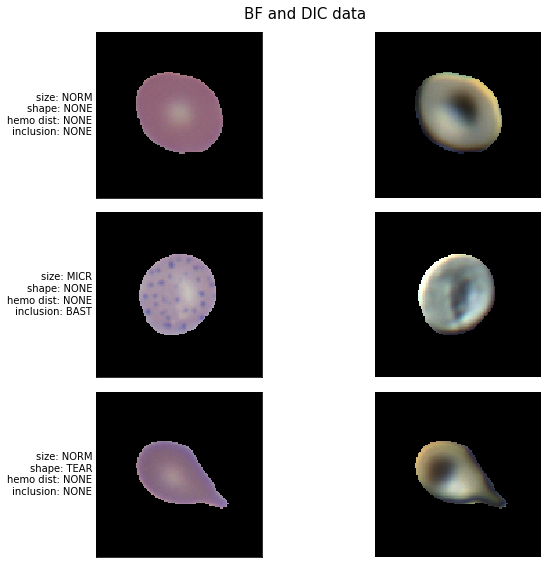

In [2]:
# DIC crops obtained are subset of BF crops, which we got by matching labels
# For supervised feature alignment, we considers the subset DIC crops and get corresponding BF crops

# source = BF(Stained crops)    target = DIC(Unstained) images
data_folder_center = 'data/dic/good_images_center'

attributes = AttributesDataset('data/all_data_new_clean1.csv')

# source and target trainset transforms for center cell  input type                                                    
to_tensor_source_trainset_full = transforms.Compose([transforms.ToTensor()])
                             

to_tensor_target_trainset_full = transforms.Compose([transforms.ToTensor()])
                              
                     
# source and target valset transforms for center cell crop

to_tensor_source_valset_full = transforms.Compose([transforms.ToTensor()])
                            

to_tensor_target_valset_full = transforms.Compose([transforms.ToTensor()])
                                               
      

train_data = ClassificationDataset(data_folder_center,'data/dic/train_processed_new_clean1.csv',attributes,\
            to_tensor_source = to_tensor_source_trainset_full, to_tensor_target = to_tensor_target_trainset_full, aug_transforms = albumentation_transforms())

val_data = ClassificationDataset(data_folder_center,'data/dic/test_new_clean.csv', attributes, \
            to_tensor_source = to_tensor_source_valset_full, to_tensor_target = to_tensor_target_valset_full)

print("Train size: %i" % len(train_data))
print("Val size: %i" % len(val_data))
print('------------------------------------------------------------------------')
print("Concatenated Img size(BF+DIC): ", train_data[0]['img'].size())
print('------------------------------------------------------------------------')
print("Size classes: ",attributes.size_labels)
print("Shape classes: ",attributes.shape_labels)
print("Hemoglobin distribution classes: ",attributes.hemo_dist_labels)
print("Inclusion classes: ",attributes.inclusion_labels)
print('------------------------------------------------------------------------')
# visualization of source data.
num_example_imgs = 3
for i, dict_item in enumerate(train_data[0:num_example_imgs]):
    
    size_label = attributes.size_id_to_name[dict_item['labels']['size_label']]
    shape_label = attributes.shape_id_to_name[dict_item['labels']['shape_label']]
    hemo_dist_label = attributes.hemo_dist_id_to_name[dict_item['labels']['hemo_dist_label']]
    inclusion_label = np.array(attributes.inclusion_labels)[np.argwhere(dict_item['labels']['inclusion_label'] > 0)[:, 0]]
    label = "size: {}\nshape: {}\nhemo dist: {}\ninclusion: {}".format(size_label, shape_label, hemo_dist_label, ', '.join(inclusion_label))
 
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    img = dict_item['img']                  #normalized between (0,1)
    img_bf = img[0:3]
    plt.imshow(img_bf.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(label, fontsize=10, rotation ='horizontal', ha ='right', va='center')
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    img_dic = img[3:6]
    plt.imshow(img_dic.numpy().transpose(1,2,0))
    plt.axis('off')
plt.suptitle("BF and DIC data", fontsize =15)      
plt.tight_layout()    
plt.show()

In [3]:
size, shape, hemo, inc_ones, inc_zeros = compute_class_weights(train_data, attributes)   
inc_ones                            

{'BAST': 3.6075,
 'HOJO': 3.6075,
 'MALA': 14.43,
 'NONE': 0.8079507278835386,
 'NRBC': 14.43,
 'PABO': 7.215,
 'RETI': 2.886}

In [4]:
import random
def set_seed(seed): 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 
    torch.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed) 
    np.random.seed(seed) 
    random.seed(seed)
    
set_seed(2021)

In [5]:
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

In [6]:
print('#### Test Case ###')
from torch.autograd import Variable

x = Variable(torch.rand(15,3,120,120)).to(device)
model = Feature_extractor().to(device)
model2= Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)
#param = count_param(model)
y = model(x)
y1 = model2(y)
print('Output shape:',y.shape)
print('Output shape:',y1['inclusion'].shape)

#### Test Case ###
Loaded pretrained weights for efficientnet-b7
Output shape: torch.Size([15, 2560])
Output shape: torch.Size([15, 7])


Loaded pretrained weights for efficientnet-b7
START TRAIN.
Epoch  0  Train src inc loss  0.37615426774252814  Train tgt inc loss  0.4217626571944216  Train mmd loss loss  0.0908196050482815  Val tgt acc hemo 0.6531543274244005
Epoch  1  Train src inc loss  0.2586790982664787  Train tgt inc loss  0.30730018137316956  Train mmd loss loss  0.012178141669527603  Val tgt acc hemo 0.7932090719499479
Epoch  2  Train src inc loss  0.20631468164995106  Train tgt inc loss  0.2544148493651043  Train mmd loss loss  0.007657530395071593  Val tgt acc hemo 0.8149765380604796
Epoch  3  Train src inc loss  0.157599341402919  Train tgt inc loss  0.20463480862306427  Train mmd loss loss  0.0052004778326212985  Val tgt acc hemo 0.9010036496350365
Epoch  4  Train src inc loss  0.13254646137047177  Train tgt inc loss  0.18286996172261205  Train mmd loss loss  0.004506758871485693  Val tgt acc hemo 0.9073905109489051
Epoch  5  Train src inc loss  0.11496854259779579  Train tgt inc loss  0.15929988909440523  

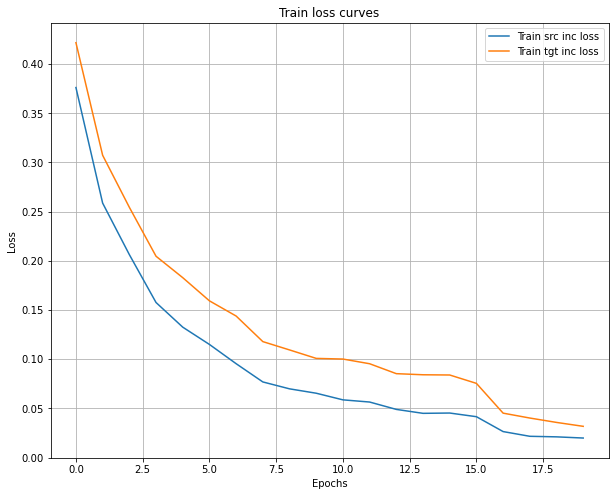

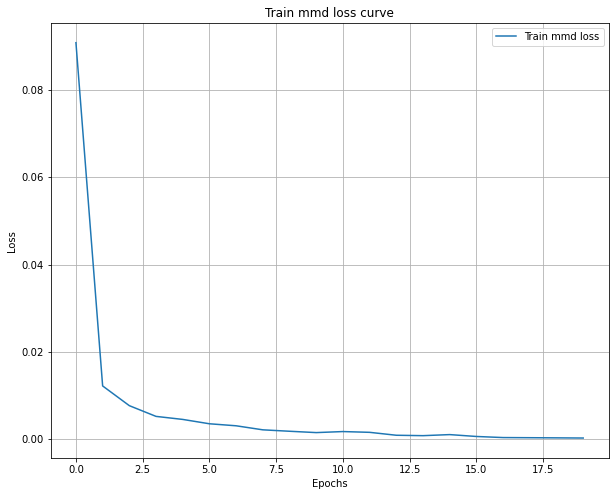

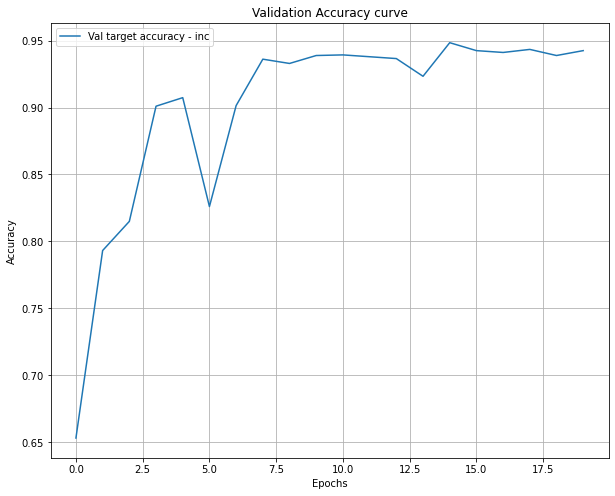

In [7]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)                       
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=16, num_workers=1)


# models
feature_extractor = Feature_extractor().to(device)
class_classifier = Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)

solver = Solver(size, shape, hemo, inc_ones, inc_zeros)       # center cell input- no dropout b/w feature extractor and classifier 
solver.train(feature_extractor, class_classifier, train_dataloader, val_dataloader, num_epochs=20)  

In [8]:
feature_extractor = Feature_extractor().to(device)
class_classifier = Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)

feature_extractor.load_state_dict(torch.load('models/center_Inc_feature_extractor_model_effi_20.pt'))
class_classifier.load_state_dict(torch.load('models/center_Inc_label_classifier_model_effi_20.pt'))

train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)                       
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=16, num_workers=1)


solver = Solver(size, shape, hemo, inc_ones, inc_zeros) 

Loaded pretrained weights for efficientnet-b7


In [9]:
model_predictions = solver.validate(feature_extractor, class_classifier, val_dataloader)#target

------------------------------------------------------------------------
Validation  accuracy inclusion: 0.9484 



[[[2155    6]
  [   6   16]]

 [[2165    2]
  [  16    0]]

 [[2153    0]
  [  22    8]]

 [[  40   90]
  [   4 2049]]

 [[2178    0]
  [   0    5]]

 [[2179    0]
  [   3    1]]

 [[2102   15]
  [  47   19]]]


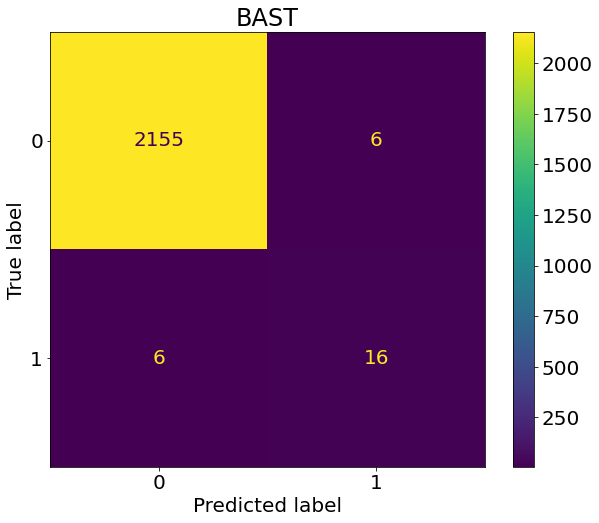

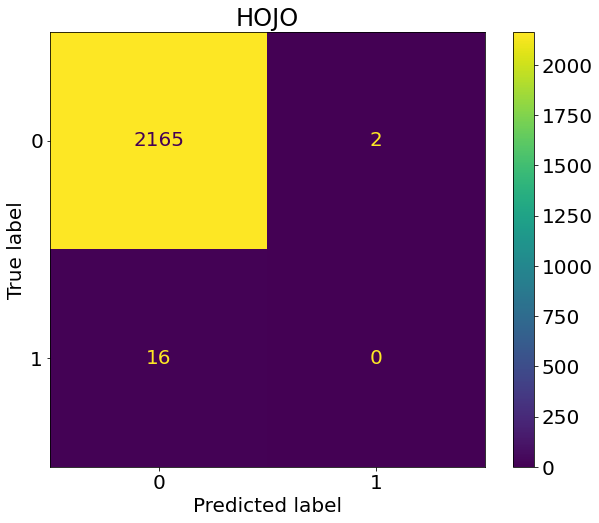

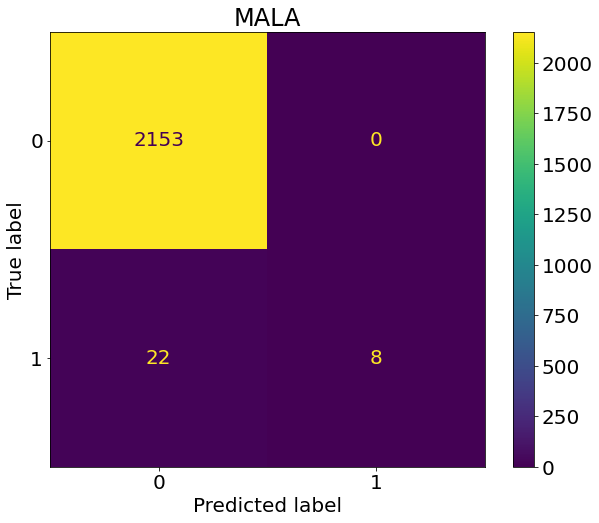

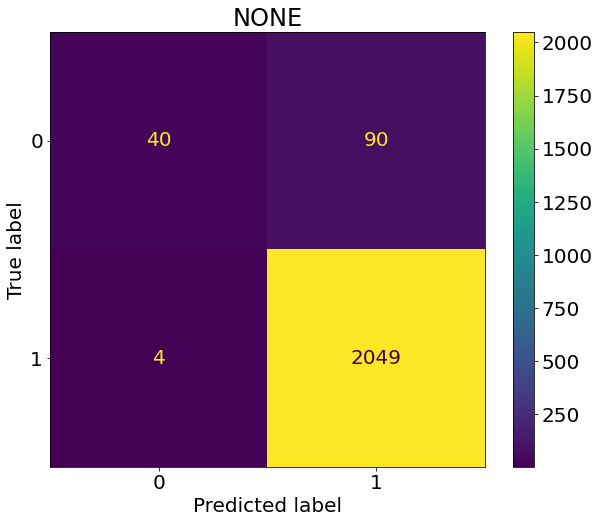

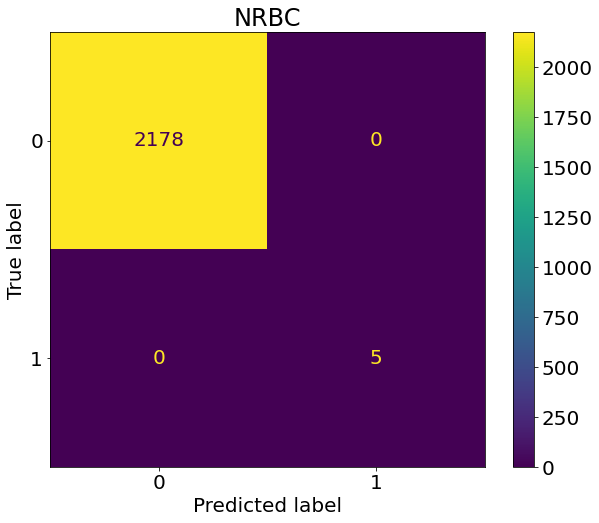

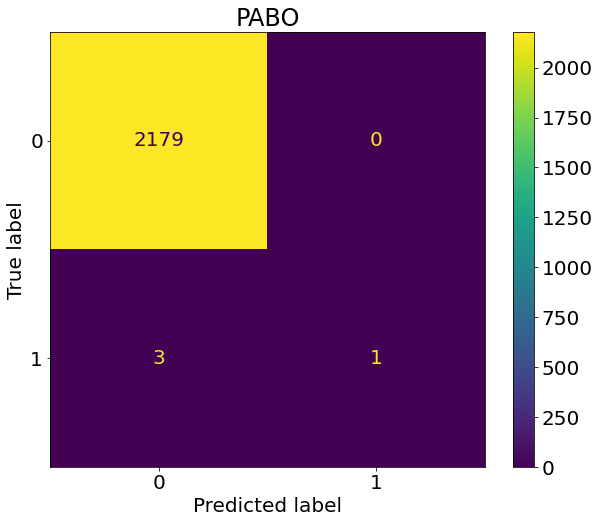

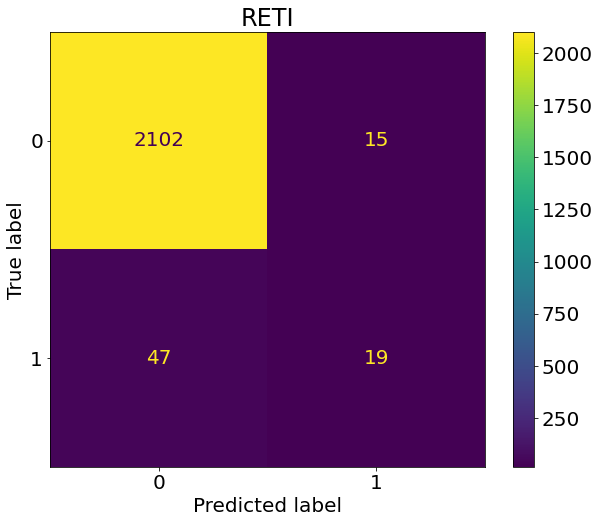

Metrics for Inclusions 
precision  [0.72727273 0.         1.         0.95792426 1.         1.
 0.55882353]
recall  [0.72727273 0.         0.26666667 0.99805163 1.         0.25
 0.28787879]
f1_score  [0.72727273 0.         0.42105263 0.97757634 1.         0.4
 0.38      ]


In [10]:
# Visualization of the trained model          #target
visualize_grid(val_data, attributes, *model_predictions)

In [11]:
model_predictions = solver.validate(feature_extractor, class_classifier, val_dataloader)#source
               # NOTE: change input index to 0 in validate function, while running source loader

------------------------------------------------------------------------
Validation  accuracy inclusion: 0.9653 



[[[2159    2]
  [   4   18]]

 [[2156   11]
  [   5   11]]

 [[2147    6]
  [   3   27]]

 [[ 106   24]
  [  15 2038]]

 [[2178    0]
  [   0    5]]

 [[2174    5]
  [   0    4]]

 [[2094   23]
  [  23   43]]]


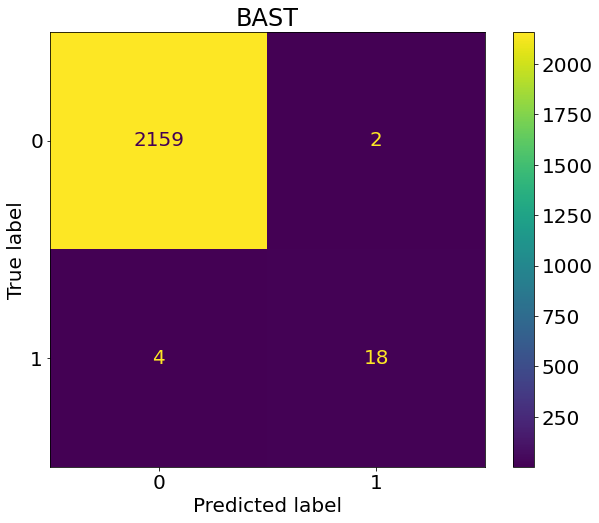

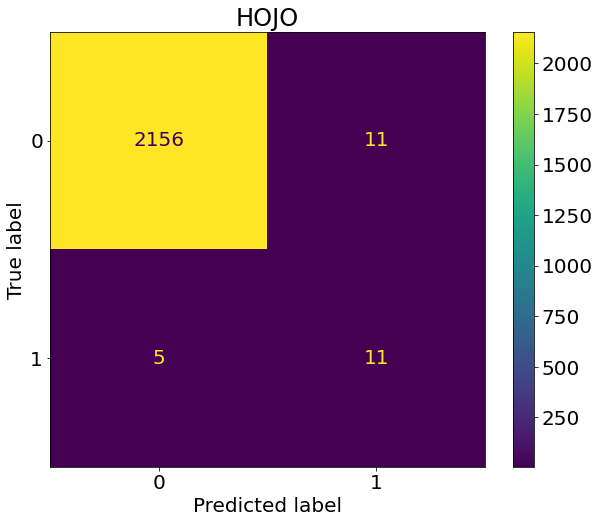

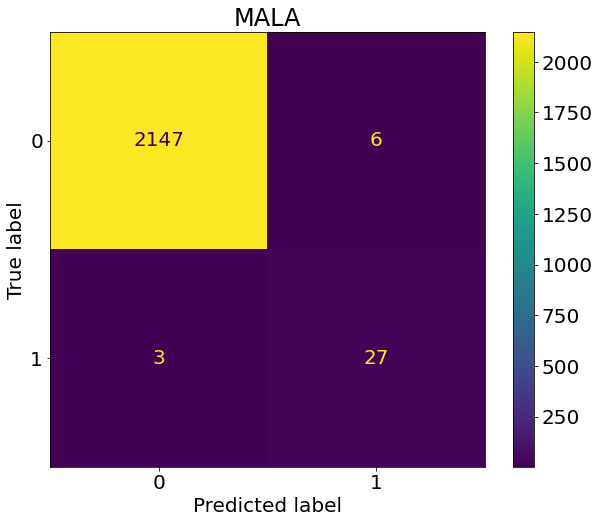

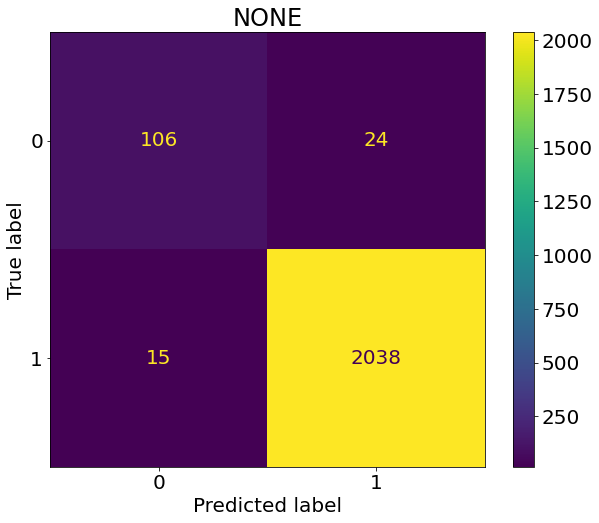

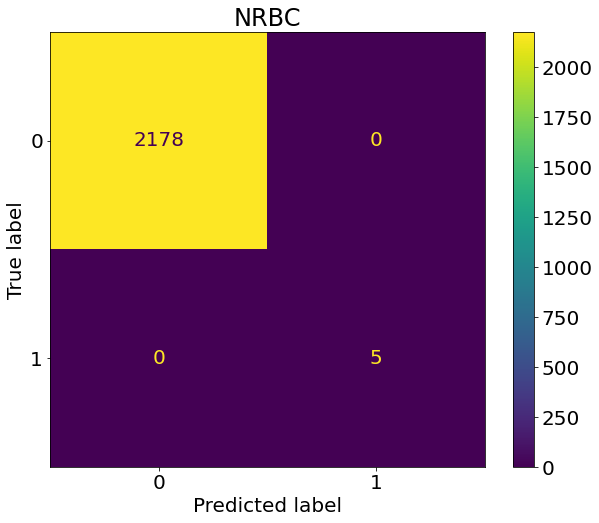

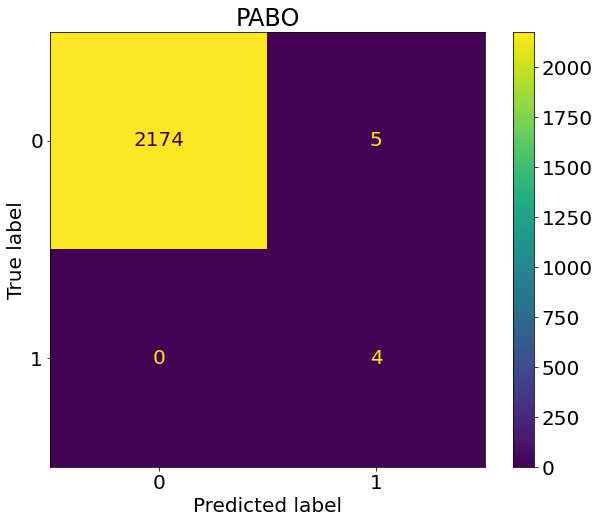

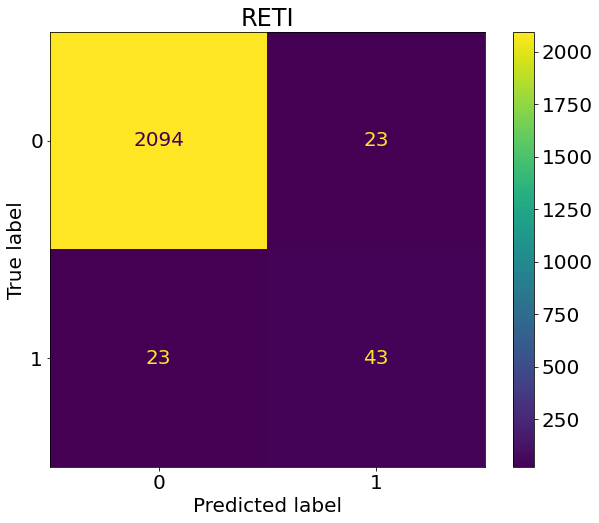

Metrics for Inclusions 
precision  [0.9        0.5        0.81818182 0.98836081 1.         0.44444444
 0.65151515]
recall  [0.81818182 0.6875     0.9        0.99269362 1.         1.
 0.65151515]
f1_score  [0.85714286 0.57894737 0.85714286 0.99052248 1.         0.61538462
 0.65151515]


In [12]:
# Visualization of the trained model          #source
visualize_grid(val_data, attributes, *model_predictions)